
# Session 3: Supervised Learning: Linear Regression (California Housing)

This notebook contains dataset with the **California Housing** dataset and covers:

- Linear Regression theory & a simple example (house price prediction)
- Implementing **cost function (MSE)** and **gradient descent** from scratch
- Choosing **learning rate**, plotting the **learning curve**
- Train/validation/test split & **cross‑validation**
- **Metrics**: MAE, MSE/RMSE, R²
- **Different forms**: Multiple Linear Regression, **Lasso**, **Ridge**, **ElasticNet**
- **Polynomial Regression** & simple feature engineering


# Implementation from Scratch

In [ ]:
# Import all the essential libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline

# Plotting settings
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)

# Helper function to display metrics consistently
def display_metrics(y_true, y_pred, label=""):
    """Calculates and prints MAE, RMSE, and R² for a model."""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    header = f"[{label}]" if label else ""
    print(f"{header:<28} MAE={mae:.3f} | RMSE={rmse:.3f} | R²={r2:.3f}")

In [ ]:
housing = fetch_california_housing(as_frame=True)

In [ ]:
features = pd.DataFrame(housing.data, columns=housing.feature_names)
target = pd.DataFrame(housing.target.rename("target"))

data = pd.concat([features, target], axis=1)

In [ ]:
# --- Data for Single-Feature Models (MedInc only) ---
X_single = data[['MedInc']].to_numpy()
y_single = data['target'].to_numpy()

# Split single-feature data (60% train, 20% val, 20% test)
X_temp, X_test_s, y_temp, y_test_s = train_test_split(
    X_single, y_single, test_size=0.2, random_state=42
)
X_train_s, X_val_s, y_train_s, y_val_s = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42 # 0.25 * 0.8 = 0.2
)

# --- Data for Multi-Feature Models (All features) ---
X_multi = housing.data
y_multi = housing.target

# Split multi-feature data (60% train, 20% val, 20% test)
X_temp_m, X_test_m, y_temp_m, y_test_m = train_test_split(
    X_multi, y_multi, test_size=0.2, random_state=42
)
X_train_m, X_val_m, y_train_m, y_val_m = train_test_split(
    X_temp_m, y_temp_m, test_size=0.25, random_state=42
)

print("Single-feature data shapes:")
print(f"Train: {X_train_s.shape}, Val: {X_val_s.shape}, Test: {X_test_s.shape}")
print("\nMulti-feature data shapes:")
print(f"Train: {X_train_m.shape}, Val: {X_val_m.shape}, Test: {X_test_m.shape}")

Single-feature data shapes:
Train: (12384, 1), Val: (4128, 1), Test: (4128, 1)

Multi-feature data shapes:
Train: (12384, 8), Val: (4128, 8), Test: (4128, 8)


In [ ]:
data.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [ ]:
print(housing.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

## Data Analysis of Features and Data Pre-processing

We analyze the data and understand the correlation between the target, which is the price of the houses, compared with all the features.

In [ ]:
correlation = data.corr("pearson")

In [ ]:
abs(correlation["target"]).sort_values(ascending=False)

,target
target,1.000000
MedInc,0.688075
AveRooms,0.151948
Latitude,0.144160
HouseAge,0.105623
AveBedrms,0.046701
Longitude,0.045967
Population,0.024650
AveOccup,0.023737


To simplify the problem for getting started, we will look at only one feature, which is MedInc (Median Income). Once we understand how linear regression works, we will look at utilizing all other features.

In [ ]:
# Feature & target
X = data[['MedInc']]
Y = data['target']

### Standardize the data

In [ ]:
X = np.array(X/X.mean())
Y = np.array(Y/Y.mean())

In [ ]:
X.shape, Y.shape

((20640, 1), (20640,))

### Train/validation/test split (60/20/20) — keep full data for training

In [ ]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42
)

In [ ]:
print("Data loaded and split into:")
print(f"Training set shape:   {X_train.shape}")
print(f"Validation set shape: {X_val.shape}")
print(f"Test set shape:       {X_test.shape}")

Data loaded and split into:
Training set shape:   (12384, 1)
Validation set shape: (4128, 1)
Test set shape:       (4128, 1)


#### Downsample to exactly 200 training points for visualization

In [ ]:
train_points = 2000
idx_plot = np.random.choice(len(X_train), size=train_points, replace=False)

X_train = X_train[idx_plot]
y_train = y_train[idx_plot]

print(f"Training scatter sample: ({train_points}, 1)")

Training scatter sample: (2000, 1)


In [ ]:
validation_points = 500
idx_plot = np.random.choice(len(X_val), size=validation_points, replace=False)

X_val = X_val[idx_plot]
y_val = y_val[idx_plot]

In [ ]:
test_points = 500
idx_plot = np.random.choice(len(X_test), size=test_points, replace=False)

X_test = X_test[idx_plot]
y_test = y_test[idx_plot]

In [ ]:
print("Data loaded and split into:")
print(f"Training set shape:   {X_train.shape}")
print(f"Validation set shape: {X_val.shape}")
print(f"Test set shape:       {X_test.shape}")

Data loaded and split into:
Training set shape:   (2000, 1)
Validation set shape: (500, 1)
Test set shape:       (500, 1)


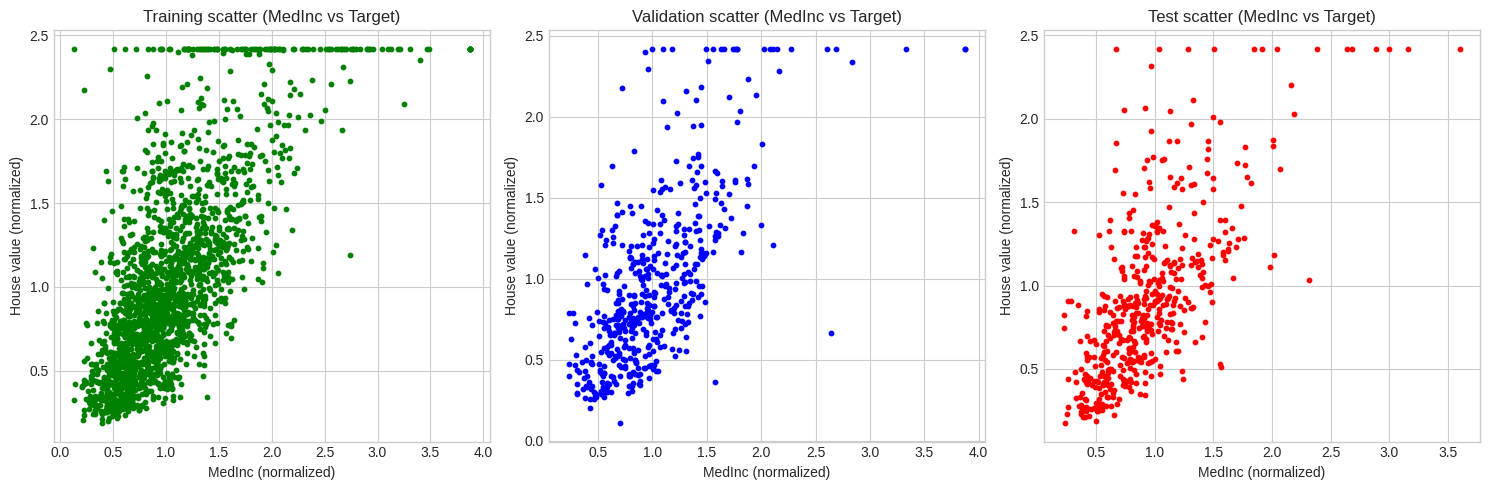

In [ ]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.scatter(X_train, y_train, c="green", s=10)
plt.xlabel("MedInc (normalized)")
plt.ylabel("House value (normalized)")
plt.title("Training scatter (MedInc vs Target)")

plt.subplot(1, 3, 2)
plt.scatter(X_val, y_val, c="blue", s=10)
plt.xlabel("MedInc (normalized)")
plt.ylabel("House value (normalized)")
plt.title("Validation scatter (MedInc vs Target)")

plt.subplot(1, 3, 3)
plt.scatter(X_test, y_test, c="red", s=10)
plt.xlabel("MedInc (normalized)")
plt.ylabel("House value (normalized)")
plt.title("Test scatter (MedInc vs Target)")

plt.tight_layout()
plt.show()

## Part 1: Linear Regression from Scratch

We'll start by building a simple linear regression model from the ground up to understand its core mechanics. We will fit the model $\hat{y} = wX + b$.

**Cost Function (Mean Squared Error):**
$$ J(w,b) = \frac{1}{N}\sum_{i=1}^{N} (y_i - \hat{y}_i)^2 $$

**Gradients (Partial Derivatives of J):**
$$ \frac{\partial J}{\partial w} = -\frac{2}{N}\sum_{i=1}^{N} x_i (y_i - \hat{y}_i) $$
$$ \frac{\partial J}{\partial b} = -\frac{2}{N}\sum_{i=1}^{N} (y_i - \hat{y}_i) $$

In [ ]:
def model(w, x, b):
    """Linear model prediction."""
    return w * x + b

In [ ]:
def mse(w, b, x, y):
    """Calculates the mean squared error cost."""
    return np.mean(np.power(((model(w, x, b)).ravel() - y), 2))

In [ ]:
def step_gradient(w, b, x, y, lr=0.01):
    """Performs a single gradient descent step."""
    grad_w = 0
    grad_b = 0

    N = len(x)

    # Calculate the error for each data point
    errors = model(w, x, b).ravel() - y

    # Calculate gradients based on the errors
    grad_w = (2/N) * np.sum(x.ravel() * errors)
    grad_b = (2/N) * np.sum(errors)

    w = w - lr * grad_w
    b = b - lr * grad_b

    return w, b

In [ ]:
def gradient_descent(x, y, learning_rate=0.05, iters=100, initial_w=0.0, initial_b=0.0):
    w, b = initial_w, initial_b
    history = []
    for i in range(iters):
        error = mse(w, b, x, y) # Use the custom mse function
        history.append(error)

        if i % 10 == 0:
            print(f"Iteration {i:3d}: MSE = {error:.4f}, W = {w:.4f}, B = {b:.4f}")

        w, b = step_gradient(w, b, x, y, learning_rate)

    return w, b, history

In [ ]:
init_w = 0
init_b = 0
learning_rate = 0.001 # Reduced learning rate
iterations = 100

In [ ]:
# Train the model
final_w, final_b, history = gradient_descent(
    X_train_s, y_train_s, learning_rate, iterations, init_w, init_b
)

print(f"\nLearned params: w = {final_w:.4f}, b = {final_b:.4f}")
display_metrics(y_val_s, model(final_w, X_val_s, final_b), "From-Scratch | Val")

Iteration   0: MSE = 5.6015, W = 0.0000, B = 0.0000
Iteration  10: MSE = 2.9345, W = 0.1601, B = 0.0350
Iteration  20: MSE = 1.7237, W = 0.2678, B = 0.0591
Iteration  30: MSE = 1.1739, W = 0.3404, B = 0.0756
Iteration  40: MSE = 0.9243, W = 0.3892, B = 0.0872
Iteration  50: MSE = 0.8108, W = 0.4219, B = 0.0954
Iteration  60: MSE = 0.7593, W = 0.4439, B = 0.1013
Iteration  70: MSE = 0.7358, W = 0.4587, B = 0.1057
Iteration  80: MSE = 0.7250, W = 0.4685, B = 0.1090
Iteration  90: MSE = 0.7201, W = 0.4751, B = 0.1117

Learned params: w = 0.4794, b = 0.1139
[From-Scratch | Val]         MAE=0.619 | RMSE=0.857 | R²=0.466


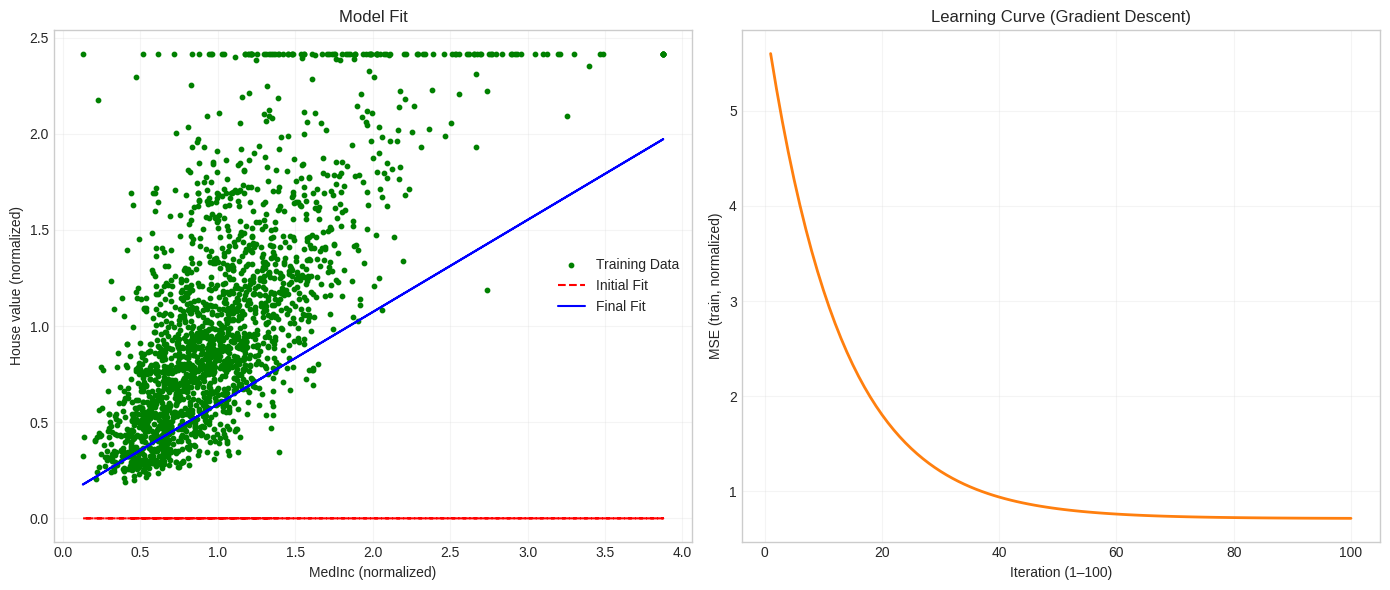

In [ ]:
plt.figure(figsize=(14, 6))

# Plot 1: Model Fit
plt.subplot(1, 2, 1)
# Use plt.scatter for data points
plt.scatter(X_train, y_train, c='green', s=10, label='Training Data')
# CORRECTED: Fixed the argument order for the model function
plt.plot(X_train, model(init_w, X_train, init_b), 'r--', label='Initial Fit')
plt.plot(X_train, model(final_w, X_train, final_b), 'b-', label='Final Fit')
plt.xlabel("MedInc (normalized)")
plt.ylabel("House value (normalized)")
plt.title("Model Fit")
plt.legend()
plt.grid(alpha=0.2)


# Plot 2: Learning Curve
plt.subplot(1, 2, 2)
plt.plot(np.arange(1, len(history)+1), history, color="tab:orange", linewidth=2)
plt.xlabel(f"Iteration (1–{iterations})")
plt.ylabel("MSE (train, normalized)")
plt.title("Learning Curve (Gradient Descent)")
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

## Part 2: Linear Regression with `scikit-learn`

Now, we'll transition to using `scikit-learn`, a powerful and efficient library for machine learning. This allows us to build more complex and robust models with less code.

In [ ]:
# Define a 5-fold cross-validation strategy
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Create two pipelines: one with scaling, one without
pipe_no_scale = Pipeline([("linreg", LinearRegression())])
pipe_scaled = Pipeline([("scaler", StandardScaler()), ("linreg", LinearRegression())])

# Helper function to run and evaluate a pipeline with CV
def get_cv_rmse(pipeline, X, y):
    scores = cross_val_score(pipeline, X, y, cv=cv, scoring="neg_root_mean_squared_error")
    return -scores

# Calculate RMSE for both pipelines on the single-feature data
rmse_raw = get_cv_rmse(pipe_no_scale, X_single, y_single)
rmse_scaled = get_cv_rmse(pipe_scaled, X_single, y_single)

print(f"RMSE (no scaling):   {rmse_raw.mean():.3f} ± {rmse_raw.std():.3f}")
print(f"RMSE (with scaling): {rmse_scaled.mean():.3f} ± {rmse_scaled.std():.3f}")

RMSE (no scaling):   0.837 ± 0.009
RMSE (with scaling): 0.837 ± 0.009


In [ ]:
## Multiple Linear Regression (All Features)

# --- 1) Using a scikit-learn Pipeline ---
pipe_all = Pipeline([
    ("scaler", StandardScaler()),
    ("linreg", LinearRegression())
])
pipe_all.fit(X_train_m, y_train_m)

print("--- scikit-learn Pipeline Metrics ---")
for name, X, y in [("Train", X_train_m, y_train_m), ("Val", X_val_m, y_val_m), ("Test", X_test_m, y_test_m)]:
    y_pred = pipe_all.predict(X)
    display_metrics(y, y_pred, f"All Features | {name}")

# --- 2) Using the Normal Equation ---
# Formula: W = (XᵀX)⁻¹Xᵀy
def add_intercept(X):
    return np.hstack([np.ones((X.shape[0], 1)), X])

X_train_i = add_intercept(X_train_m.to_numpy())
X_val_i   = add_intercept(X_val_m.to_numpy())
X_test_i  = add_intercept(X_test_m.to_numpy())

# Solve for W using the pseudo-inverse (pinv) for numerical stability
W_normal_eq = np.linalg.pinv(X_train_i.T @ X_train_i) @ X_train_i.T @ y_train_m

print("\n--- Normal Equation Metrics ---")
for name, X, y in [("Train", X_train_i, y_train_m), ("Val", X_val_i, y_val_m), ("Test", X_test_i, y_test_m)]:
    y_pred = X @ W_normal_eq
    display_metrics(y, y_pred, f"Normal Eq. | {name}")

--- scikit-learn Pipeline Metrics ---
[All Features | Train]       MAE=0.527 | RMSE=0.717 | R²=0.612
[All Features | Val]         MAE=0.533 | RMSE=0.728 | R²=0.614
[All Features | Test]        MAE=0.533 | RMSE=0.750 | R²=0.571

--- Normal Equation Metrics ---
[Normal Eq. | Train]         MAE=0.527 | RMSE=0.717 | R²=0.612
[Normal Eq. | Val]           MAE=0.533 | RMSE=0.728 | R²=0.614
[Normal Eq. | Test]          MAE=0.533 | RMSE=0.750 | R²=0.571


## Regularization: Ridge, Lasso, and ElasticNet

In [ ]:
## Regularization: Ridge, Lasso, and ElasticNet

# alpha: Regularization strength. Larger values mean stronger regularization.
# l1_ratio: For ElasticNet, the mix between L1 (Lasso) and L2 (Ridge) penalties.
models = {
    "Ridge": Ridge(alpha=1.0, random_state=42),
    "Lasso": Lasso(alpha=0.001, max_iter=10000, random_state=42),
    "ElasticNet": ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=10000, random_state=42)
}

print("--- Regularized Model CV Performance (All Features) ---")
for name, model in models.items():
    pipe = Pipeline([("scaler", StandardScaler()), (name, model)])
    rmse_scores = get_cv_rmse(pipe, X_multi, y_multi)
    print(f"{name:<12} | CV RMSE: {rmse_scores.mean():.3f} ± {rmse_scores.std():.3f}")

--- Regularized Model CV Performance (All Features) ---
Ridge        | CV RMSE: 0.728 ± 0.015
Lasso        | CV RMSE: 0.728 ± 0.015
ElasticNet   | CV RMSE: 0.728 ± 0.015


## Polynomial Regression (on MedInc)

[Polynomial (d=3) | Val]     MAE=0.617 | RMSE=0.829 | R²=0.499


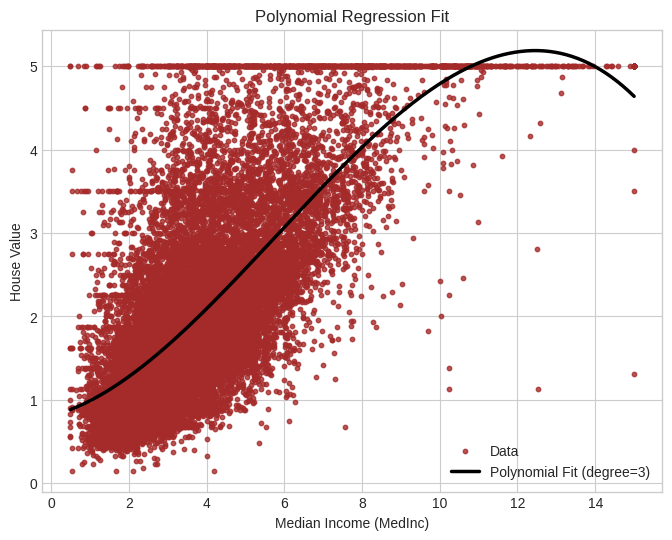

In [ ]:
## Polynomial Regression (on MedInc)

# Create a pipeline that generates polynomial features, scales them, and fits a model
poly_pipe = Pipeline([
    ("poly", PolynomialFeatures(degree=3, include_bias=False)),
    ("scaler", StandardScaler()),
    ("linreg", LinearRegression())
])
poly_pipe.fit(X_train_s, y_train_s)

# Evaluate on the validation set
y_pred_poly = poly_pipe.predict(X_val_s)
display_metrics(y_val_s, y_pred_poly, "Polynomial (d=3) | Val")

# --- Plot the resulting non-linear fit ---
x_line = np.linspace(X_single.min(), X_single.max(), 200).reshape(-1, 1)
y_line = poly_pipe.predict(x_line)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(X_single, y_single, c="brown", alpha=0.8, s=10, label="Data")
ax.plot(x_line, y_line, color="black", linewidth=2.5, label="Polynomial Fit (degree=3)")
ax.set_xlabel("Median Income (MedInc)")
ax.set_ylabel("House Value")
ax.set_title("Polynomial Regression Fit")
ax.legend()
plt.show()

### Key Takeaways

-   **From-Scratch vs. Library**: Implementing algorithms from scratch is excellent for learning, but `scikit-learn` provides optimized, robust, and feature-rich implementations for practical use.
-   **Feature Scaling**: Always **standardize** features before using gradient-based or regularized models. It is one of the most important preprocessing steps.
-   **Bias-Variance Tradeoff**: Regularization (Ridge, Lasso, ElasticNet) adds a penalty to prevent overfitting, increasing model bias slightly to significantly reduce variance.
-   **Cross-Validation**: Use **cross-validation** as a robust method for estimating model performance and for tuning hyperparameters (e.g., `alpha`, `degree`).
-   **Feature Engineering**: If the relationship between features and the target is non-linear, creating **polynomial features** can dramatically improve a linear model's performance.